In [1]:
import openmm as mm
import openmm.app as app 
import openmm.unit as unit
from boltzkit.utils.plot_molecule import plot_matplotlib_molecule

convert to nanometers


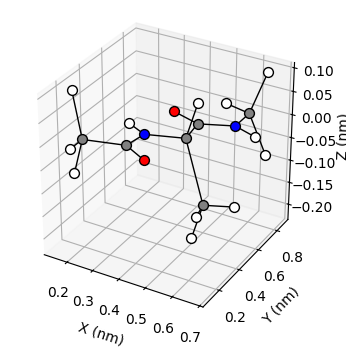

In [23]:
pdb_file_path = "data/alanine-dipeptide-implicit.pdb"
pdb = app.PDBFile(pdb_file_path)

plot_matplotlib_molecule(pdb.topology, pdb.positions)

In [ ]:
"""
A likely incomplete list of AMBER force field versions:

- 1997 amber96.xml: Minor update of ff94 with ab initio data.
- 2003 amber03.xml: ff99SB torsions refitted to ab initio data (AMBER ff03).
- 2006 amber99sb.xml: Refined ff94 side-chain & backbone torsions (AMBER ff99SB).
- 2010 amber99sbildn.xml: ff99SB side-chains refitted to NMR data (ff99SB-ILDN).
- 2010 amber99sbnmr.xml: Alternative NMR refit of ff99SB (less common).
- ???? amber10.xml: Unclear origin; likely intermediate toward ff14SB.
- 2015 amber14-all.xml / amber14/protein.xml: Improved side-chain & backbone from ff99SB (AMBER ff14SB).
"""

forcefield = app.ForceField("amber14-all.xml")
system: mm.System = forcefield.createSystem(pdb.topology, nonbondedCutoff=3 * unit.nanometer, constraints=app.HBonds)
# nonbondedCutoff: Limit interaction radius for non-bonded atoms
# constraints: Constraints removing degrees of freedom (e.g., app.HBonds prevents bonds to hydrogen atoms from vibrating -> keeps them fixed length, which allows larger simulation timesteps)

integrator = mm.LangevinIntegrator(300 * unit.kelvin, 1 / unit.picosecond, 2 * unit.femtoseconds)
simulation = app.Simulation(pdb.topology, system, integrator)

# Conversion from numpy to mm.Vec3 avoids the numpy ABI incompatibility as openmm is only pre-compiled for numpy<2 but numpy>=2 is installed.
positions = [mm.Vec3(x, y, z) for x, y, z in pdb.positions]
simulation.context.setPositions(pdb.positions)

# optimization is deterministic 
simulation.minimizeEnergy() 

state: mm.State = simulation.context.getState(getPositions=True)
minimized_positions: unit.Quantity = state.getPositions()
print("minimum energy positions:", minimized_positions)

minimum energy positions: [Vec3(x=0.19429214289258312, y=0.12097161067474493, z=0.06586629030419877), Vec3(x=0.19932163770543965, y=0.2170297462860559, z=0.01459704463185242), Vec3(x=0.13177397874481508, y=0.2878164190864682, z=0.06263405071176772), Vec3(x=0.1716827949051049, y=0.20409796612318945, z=-0.09004451985907792), Vec3(x=0.34082925599042974, y=0.26929791893336813, z=0.022511345324426394), Vec3(x=0.42898100085358787, y=0.2008322291737223, z=0.07274378169630481), Vec3(x=0.36211519812791304, y=0.3910684475496615, z=-0.026736503744756158), Vec3(x=0.2837619740627427, y=0.4433899391005988, z=-0.0631265410440827), Vec3(x=0.4916214702039616, y=0.4590584204780348, z=-0.02742998663084466), Vec3(x=0.5480767722255826, y=0.428433010509982, z=0.06063751370901306), Vec3(x=0.5692969771315488, y=0.4159452519585539, z=-0.15270212197770175), Vec3(x=0.5143146559593657, y=0.44505997387480456, z=-0.24220226319771196), Vec3(x=0.667442102025217, y=0.463346854086496, z=-0.15397211146004985), Vec3(x=0.

convert to nanometers


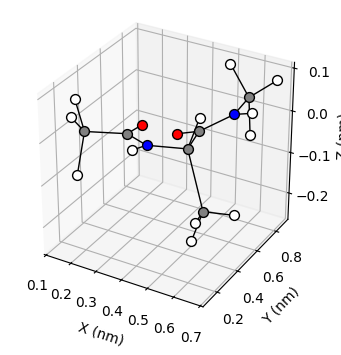

In [29]:
plot_matplotlib_molecule(pdb.topology, minimized_positions)